In [8]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


inspection_id = "0A49KLT3B7Y" #fhr8
angle_profiles = ["0"]
num_tracks = 22
run_number = 8

In [9]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

results_dir = f"./data-files/insp_{inspection_id}_dent_detection_ae_reruns_research"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
download_s3_folder("dv-ilit0008", f"track_runs_research/{inspection_id}/dent_detection_ae/", results_dir)


In [10]:
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [11]:
len(data_files), data_files

(27,
 [PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_reruns_research/distance_0000000000.0_0000001000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_reruns_research/distance_0000001000.0_0000002000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_reruns_research/distance_0000002000.0_0000003000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_reruns_research/distance_0000003000.0_0000004000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_reruns_research/distance_0000004000.0_0000005000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_reruns_research/distance_0000005000.0_0000006000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_reruns_research/distance_0000006000.

In [12]:
pd.read_csv(data_files[0])

,start,end,prob
0,-0.15,0.15,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,0.00,0.30,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,0.15,0.45,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,0.30,0.60,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,0.45,0.75,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...
6664,999.45,999.75,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6665,999.60,999.90,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6666,999.75,1000.05,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6667,999.90,1000.20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [13]:
## Create a DataFrame for each profile and track and range
def create_df(frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files]
    else:
        data_files_range = [f for f in data_files if f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]


    dfs = []
    for path in data_files_range:
        df = pd.read_csv(path)
        dfs.append(df)

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

Threshold 0.050: 268/175431 passed (268/175431 positives, 0.1528%)
Threshold 0.400: 179/175431 passed (179/175431 positives, 0.1020%)
Threshold 0.500: 168/175431 passed (168/175431 positives, 0.0958%)
Threshold 0.600: 163/175431 passed (163/175431 positives, 0.0929%)
Threshold 0.700: 154/175431 passed (154/175431 positives, 0.0878%)
Threshold 0.800: 137/175431 passed (137/175431 positives, 0.0781%)
Threshold 0.900: 107/175431 passed (107/175431 positives, 0.0610%)
Threshold 0.970: 67/175431 passed (67/175431 positives, 0.0382%)
Threshold 0.990: 45/175431 passed (45/175431 positives, 0.0257%)


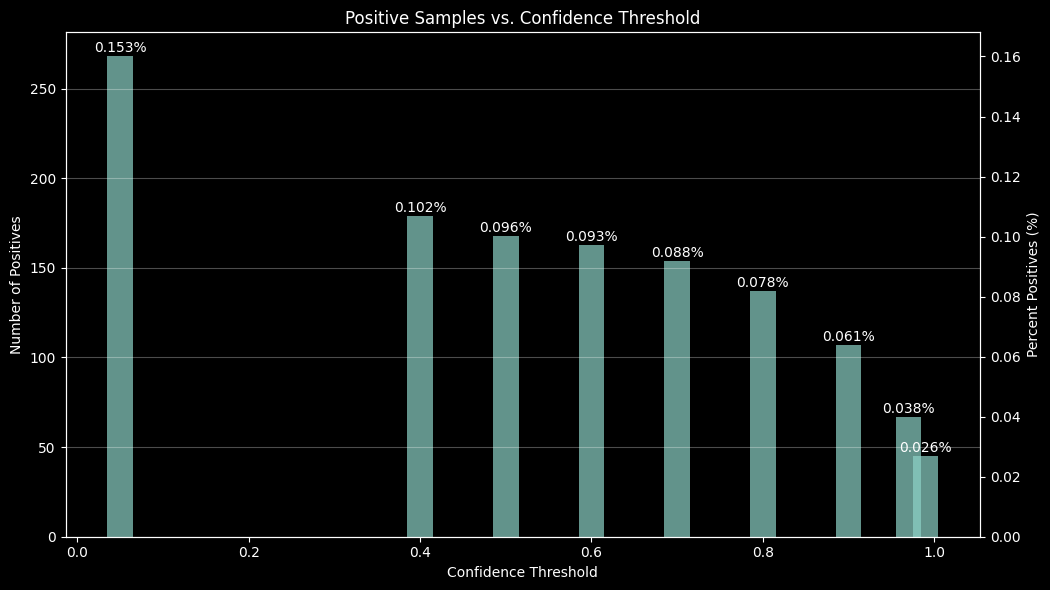

In [14]:
# Assuming all_dfs is your dataframe with columns: start, end, and prob
import ast

# Function to parse probability strings into actual lists if needed
def parse_prob(prob_str):
    """Convert string representation of list to actual list if needed"""
    if isinstance(prob_str, str):
        try:
            return ast.literal_eval(prob_str)
        except:
            return []
    return prob_str

# Process each threshold
thresholds = [0.05,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.97, 0.99]
results = []
all_dfs = create_df()

for threshold in thresholds:
    # Lists to store entries that pass the threshold
    filtered_entries = []
    total_samples = len(all_dfs)
    num_positives = 0
    
    # Process each row
    for i, row in all_dfs.iterrows():
        # Parse the probability values if needed
        probs = parse_prob(row['prob'])
        
        # Check if any probability exceeds the threshold
        if any(p >= threshold for p in probs):
            # Add this entry to our filtered list
            filtered_entries.append({
                'start': row['start'],
                'end': row['end'],
                'prob': probs,
                'max_prob': max(probs)
            })
            num_positives += 1
    
    # Store results for this threshold
    results.append({
        'threshold': threshold,
        'filtered_entries': filtered_entries,
        'num_positives': num_positives,
        'total': total_samples,
        'num_positives_percent': (num_positives / total_samples) * 100 if total_samples > 0 else 0
    })
    print(f"Threshold {threshold:.3f}: {len(filtered_entries)}/{total_samples} passed "
          f"({num_positives}/{total_samples} positives, {num_positives/total_samples:.4%})")

# Plotting the results
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Extract data for plotting
thresholds = [r['threshold'] for r in results]
num_positives_counts = [r['num_positives'] for r in results]
num_positives_percent = [r['num_positives_percent'] for r in results]

# Create bar plot
bars = plt.bar(thresholds, num_positives_counts, width=0.03, alpha=0.7)

# Add percentage labels on top of bars
for bar, percent in zip(bars, num_positives_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{percent:.3f}%', ha='center', va='bottom')


# Add labels and title
plt.xlabel('Confidence Threshold')
plt.ylabel('Number of Positives')
plt.title('Positive Samples vs. Confidence Threshold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add second y-axis for percentage
ax2 = plt.gca().twinx()
ax2.set_ylabel('Percent Positives (%)')
ax2.plot(thresholds, num_positives_percent, 'r-', alpha=0)  # Invisible, just for scale
ax2.set_ylim(0, max(num_positives_percent) * 1.1)

plt.show()

In [15]:
# Access filtered entries for threshold 0.9
entries_09 = results[2]['filtered_entries']  # Index 5 corresponds to threshold 0.9
print(f"Found {len(entries_09)} entries")

# Optional: Create a new DataFrame with filtered entries
import pandas as pd
filtered_df = pd.DataFrame(entries_09)
display(filtered_df)

Found 168 entries


,start,end,prob,max_prob
0,1.20,1.50,"[0.0005, 0.0, 0.0036, 0.0, 0.0, 0.019, 0.0, 0....",0.9591
1,1.35,1.65,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9049
2,1.50,1.80,"[0.0, 0.0, 0.0001, 0.0001, 0.005, 0.0001, 0.0,...",0.8476
3,2.10,2.40,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.147...",0.8477
4,2.40,2.70,"[0.919, 0.792, 0.9222, 0.0037, 0.0, 0.0019, 0....",0.9222
...,...,...,...,...
163,26304.50,26304.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0003, 0.0735, 0.00...",0.7986
164,26304.65,26304.95,"[0.0018, 0.0002, 0.001, 0.0, 0.0, 0.0001, 0.00...",0.9591
165,26304.80,26305.10,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.000...",0.9899
166,26304.95,26305.25,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0003, 0.876, 0.000...",0.8760


In [16]:
def filter_close_detections(df, distance_threshold=0.2):
    """
    Filter out detections that are close to each other.
    When multiple detections are within distance_threshold, keep only the one with larger start value.
    
    Args:
        df: DataFrame with 'start' column
        distance_threshold: Maximum allowed distance between starts (default 0.2)
        
    Returns:
        DataFrame with filtered rows
    """
    if len(df) <= 1:
        return df
    
    # Sort by start column in descending order (larger values first)
    df_sorted = df.sort_values(by='start', ascending=False).reset_index(drop=True)
    
    # Initialize with first row (largest start value)
    kept_indices = [0]
    last_kept_start = df_sorted.loc[0, 'start']
    
    # Process remaining rows
    for i in range(1, len(df_sorted)):
        current_start = df_sorted.loc[i, 'start']
        
        # If far enough from last kept row, keep this one too
        # Note: Since we're going from larger to smaller, the comparison is flipped
        if last_kept_start - current_start >= distance_threshold:
            kept_indices.append(i)
            last_kept_start = current_start
    
    # Return dataframe with only kept rows
    return df_sorted.loc[kept_indices].reset_index(drop=True)

# Example usage
filtered_df_deduped = filter_close_detections(filtered_df)
print(f"Original detections: {len(filtered_df)}")
print(f"After deduplication: {len(filtered_df_deduped)}")

Original detections: 168
After deduplication: 132


In [17]:
import sys
import os

# Add parent directory to path (adjust as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to Python path")
    
from rnd.utils.data_utils import (
    extract_arm_angles,
    create_arm_array,
)
from ilipy import Session
from ilipy.database import DistanceCorrelation

root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)

session = Session(environment="prod")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

def gen_image(img_start, session, dist_corr, length= 0.3, show_im=True, normalize="range"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=num_tracks,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.colorbar()
        plt.show()
    return img


Added /home/zmirikha/GitHub/rnd_q2 to Python path
PySettings.cpp(46): ilipy: Build 0.18.0.12150 f0baf65fb3 release-ili-0.18 'Tue Oct 21 19:59:39 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/prod.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.

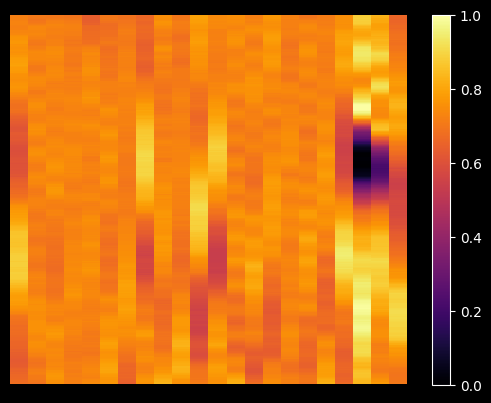

In [18]:
img_std = gen_image(7984.89, session, dist_corr, length=0.3, show_im=True, normalize="std")

In [19]:
# for i, row in filtered_df_deduped.iterrows():
#     vd = (row['start']+ row['end'])/2
#     img_std = gen_image(row['start'], session, dist_corr, length=0.3, show_im=True, normalize="std")

#     print(vd, row['prob'])

In [20]:
import boto3
import pandas as pd
from io import BytesIO

def save_df_to_s3_parquet(df, bucket_name, s3_key):
    """
    Save DataFrame to S3 as parquet file
    
    Args:
        df: DataFrame to save
        bucket_name: S3 bucket name
        s3_key: S3 key (path) for the file
    """
    # Convert DataFrame to parquet in memory
    parquet_buffer = BytesIO()
    df.to_parquet(parquet_buffer, index=False)
    parquet_buffer.seek(0)
    
    # Upload to S3
    s3_client = boto3.client('s3')
    s3_client.put_object(
        Bucket=bucket_name,
        Key=s3_key,
        Body=parquet_buffer.getvalue(),
        ContentType='application/octet-stream'
    )
    
    print(f"DataFrame saved to s3://{bucket_name}/{s3_key}")
bucket_name = "dent-dev"
s3_key = f"dent_bookmarks/ArmDent_bookmarks_{inspection_id}.parquet"
#save_df_to_s3_parquet(filtered_df_deduped, bucket_name, s3_key)

In [21]:
from __future__ import annotations

from ilipy import Session
from ilipy.channeldata import ChannelDataReader, ImageProfile
from ilipy.features import Bookmarks

from ilipyutils.ml_features.base import (
    AnomalyStatus,
    get_ml_models_info_list,
)
from ilipyutils.ml_features.insert import FeatureInsert,GeometryCubeParameters
from ilipy import ClipTypes, TrackIndex, ViewDistance

session = Session(environment="prod")
bookmarks_interface = Bookmarks(connector=session.database_connector)

feature_insert = FeatureInsert(session=session, bookmarks_interface=bookmarks_interface)

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8080, Concurrent Connections: 1
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8080, Concurrent Connections: 1
RestApi.cpp(72): ApiService Ping Response (http://storage-dvv-01.darkvision.local:8080) : 200, 2ms
RestApi.cpp(72): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8080) : 200, 123ms


In [22]:
get_ml_models_info_list()

[MLModelInfo(model_name='ID-Corrosion-Detection-v1', model_id=0, model_score_bound=[0, 1], anomaly_type_name='Corrosion'),
 MLModelInfo(model_name='ID-Corrosion-Detection-v2', model_id=1, model_score_bound=[0, 1], anomaly_type_name='Corrosion'),
 MLModelInfo(model_name='Channel-Crack-Detection-v1', model_id=2, model_score_bound=[0, None], anomaly_type_name='Crack'),
 MLModelInfo(model_name='Beamformed-Crack-Detection-v1', model_id=6, model_score_bound=[0, 1], anomaly_type_name='Crack'),
 MLModelInfo(model_name='Dent-Detection-v1', model_id=7, model_score_bound=[0, 1], anomaly_type_name='DentPlain'),
 MLModelInfo(model_name='Channel-Crack-Detection-v2', model_id=8, model_score_bound=[0, None], anomaly_type_name='Crack'),
 MLModelInfo(model_name='Corrosion-Detection-v3', model_id=9, model_score_bound=[0, 1], anomaly_type_name='Corrosion'),
 MLModelInfo(model_name='Corrosion-Detection-v4', model_id=10, model_score_bound=[0, 1], anomaly_type_name='Corrosion'),
 MLModelInfo(model_name='Dent

In [23]:
model_info = next(
    model
    for model in get_ml_models_info_list()
    if "Dent" in model.model_name
)
model_info

MLModelInfo(model_name='Dent-Detection-v1', model_id=7, model_score_bound=[0, 1], anomaly_type_name='DentPlain')

In [24]:
model_info = next(
    model
    for model in get_ml_models_info_list()
    if model.model_name == "Dent-Detection-v3"
)
model_info

MLModelInfo(model_name='Dent-Detection-v3', model_id=12, model_score_bound=[0, 1], anomaly_type_name='DentPlain')

In [25]:
from ili_custom_data.load_model import ModelDataLoader

latest_model = ModelDataLoader.get_latest_model()

In [26]:
session = Session(environment="prod")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)
clips = session.get_clips_by_type(ClipTypes.ChannelData)

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8080, Concurrent Connections: 1
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8080, Concurrent Connections: 1
RestApi.cpp(72): ApiService Ping Response (http://storage-dvv-01.darkvision.local:8080) : 200, 3ms
RestApi.cpp(72): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8080) : 200, 123ms
PySession.cpp(84): Initialized with inspection: 0A49KLT3B7Y
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8080, Concurrent Connections: 3
PigSpatialModel.cpp(308): vehicle 4 -> disk 5 -> FrontSlot has a track assignme

In [34]:
def get_decimal_range(value):
    """
    For a number like 0.56, return (0.5, 0.6)
    For a number like 0.78, return (0.7, 0.8)
    
    Args:
        value (float): A decimal value 
        
    Returns:
        tuple: The lower and upper bounds of the decimal range
    """
    # Get the first decimal place as the lower bound
    lower = int(value * 10) / 10
    # The upper bound is just 0.1 more
    upper = round(lower + 0.1, 1)

    return lower, upper

def parse_prob_list_safe(v):
    if isinstance(v, (list, tuple)):
        return [p for p in v if isinstance(p, (int, float))]
    if isinstance(v, str):
        try:
            r = ast.literal_eval(v)
            if isinstance(r, (list, tuple)):
                return [p for p in r if isinstance(p, (int, float))]
        except Exception:
            return []
    return []

In [28]:
# anomalies = bookmarks_interface.get_anomalies(inspectionId="0A49KLT3B7Y")
# dent_anomalies = [a for a in anomalies if "Dent-Detection-v3" in a.tags]
# len(dent_anomalies)


In [29]:
# _ = [bookmarks_interface.delete_anomaly(a.feature.anomaly_feature_id) for a in dent_anomalies]

In [30]:

import numpy as np
cube_params = GeometryCubeParameters(
tlbr_cube_angle_rad=(np.deg2rad(-15), np.deg2rad(-15)),
tlbr_probe_scan_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_radial_position_mm=(1, 1),
)

In [31]:
filtered_df_deduped

,start,end,prob,max_prob
0,26305.10,26305.40,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9540
1,26304.80,26305.10,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.000...",0.9899
2,26304.50,26304.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0003, 0.0735, 0.00...",0.7986
3,26304.20,26304.50,"[0.0, 0.0, 0.0, 0.0049, 0.0, 0.0001, 0.0094, 0...",0.9574
4,26303.60,26303.90,"[0.0021, 0.0, 0.0, 0.0008, 0.0, 0.0002, 0.0068...",0.8044
...,...,...,...,...
127,2.85,3.15,"[0.0011, 0.0, 0.0, 0.0, 0.0, 0.9972, 0.0075, 0...",0.9972
128,2.55,2.85,"[0.0, 0.0, 0.0002, 0.0, 0.0, 0.0017, 0.0001, 0...",0.9578
129,2.10,2.40,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.147...",0.8477
130,1.50,1.80,"[0.0, 0.0, 0.0001, 0.0001, 0.005, 0.0001, 0.0,...",0.8476


In [32]:
j=0
for i, row in filtered_df_deduped.iterrows():

        print(i)
        profile = ImageProfile.ZeroAngle 
        vd_start, vd_end, probs_raw = row['start'], row['end'], row['prob']
        probs = parse_prob_list_safe(probs_raw)
        arg_max_probs = [idx for idx, p in enumerate(probs) if p >= 0.7]

        for arg_max_prob in arg_max_probs:
            print(j)
            j+=1
            track_nums = (arg_max_prob,arg_max_prob+1)
            bookmark_conf_score = probs[arg_max_prob]
            start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_nums[0]), ViewDistance(vd_start)).value
            end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_nums[1]), ViewDistance(vd_end)).value
            model_instance = latest_model(
            ml_confidence_score=bookmark_conf_score,)
            lower_bound, upper_bound = get_decimal_range(bookmark_conf_score)
            extra_tags = {f"threshold_bin-{lower_bound}-{upper_bound}"}
            model_instance = latest_model(
            ml_confidence_score=bookmark_conf_score,)

            # anomaly_info = feature_insert.insert_ml_pred(
            # inspection_id=inspection_id,
            # tlbr_track_indices=track_nums,
            # tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
            # cube_params=cube_params,
            # model_info=model_info,
            # anomaly_status=AnomalyStatus.REVIEW_DETECTION,
            # image_profile=profile,
            # extra_tags=extra_tags,
            # ili_custom_data=model_instance
            # )


0
0
1
1
2
2
3
3
4
4
5
5
6
6
7
7
8
8
9
9
10
10
11
12
11
13
12
14
13
15
14
16
15
17
16
18
17
19
18
19
20
20
21
21
22
22
23
23
24
24
25
26
25
27
28
26
29
27
30
28
31
29
32
33
30
34
31
35
32
36
37
33
38
34
39
35
40
36
41
42
43
37
44
38
45
39
46
40
47
41
42
48
49
43
50
44
51
45
52
46
53
47
54
48
55
49
56
57
50
58
51
59
52
60
53
61
54
62
55
63
56
57
64
58
65
59
66
67
60
68
69
70
61
71
62
72
73
63
74
64
75
65
76
77
66
78
79
67
80
68
81
69
82
70
71
83
84
72
73
85
74
86
75
87
76
88
89
90
91
77
92
78
93
94
79
95
96
80
97
81
98
82
99
83
100
84
101
85
102
86
87
103
88
104
89
105
90
106
91
107
92
108
93
109
94
110
95
111
96
112
97
113
98
114
99
115
100
101
116
102
117
103
118
104
119
105
120
106
121
107
122
108
123
109
124
110
125
111
126
112
127
113
114
128
115
129
116
130
117
131
118
132
133
119
134
120
135
136
121
137
138
122
123
139
124
140
141
142
125
143
126
144
127
145
128
146
147
129
148
130
149
131
150


In [33]:
#Found this new dents
22456.600
20803.85
7985.04
6410.54
6389.099999999056 

6389.099999999056